In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [21]:
data=load_breast_cancer()
X=data.data
y=data.target
features=data.feature_names
class_name=data.target_names

In [22]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.3
)

In [23]:
print(X_train.shape)

(398, 30)


In [24]:
scaler=StandardScaler()
X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)
print(X_train.shape)

(398, 30)


choose optimal k simple search

In [ ]:
best_k=None
best_acc=0
for k in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=k,
                             metric="euclidean")
    knn.fit(X_train_scale,y_train)
    y_pred=knn.predict(X_test_scale)
    acc=accuracy_score(y_test,y_pred)
    if acc>best_acc:
        best_acc=acc
        best_k=k
print(f"best value of k is:{best_k} with accuracy is:{acc:.4f}")


Best value of k: 3
Best accuracy: 0.9591

Accuracy for each k:
k=1: accuracy=0.9474
k=2: accuracy=0.9240
k=3: accuracy=0.9591
k=4: accuracy=0.9415
k=5: accuracy=0.9532
k=6: accuracy=0.9357
k=7: accuracy=0.9532
k=8: accuracy=0.9474
k=9: accuracy=0.9532
k=10: accuracy=0.9532
k=11: accuracy=0.9532
k=12: accuracy=0.9532
k=13: accuracy=0.9474
k=14: accuracy=0.9474
k=15: accuracy=0.9474
k=16: accuracy=0.9532
k=17: accuracy=0.9474
k=18: accuracy=0.9474
k=19: accuracy=0.9474
k=20: accuracy=0.9474


In [28]:
pca=PCA(n_components=10)
X_train_pca=pca.fit_transform(X_train_scale)
X_test_pca=pca.transform(X_test_scale)
print("the resuced dimensions is:",X_train_pca.shape)


the resuced dimensions is: (398, 10)


In [30]:
knn_pca = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean"
)

knn_pca.fit(X_train_pca, y_train)

y_pred_pca = knn_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"Best value of k: {best_k}")
print(f"PCA KNN accuracy: {acc_pca:.4f}")

Best value of k: 3
PCA KNN accuracy: 0.9532


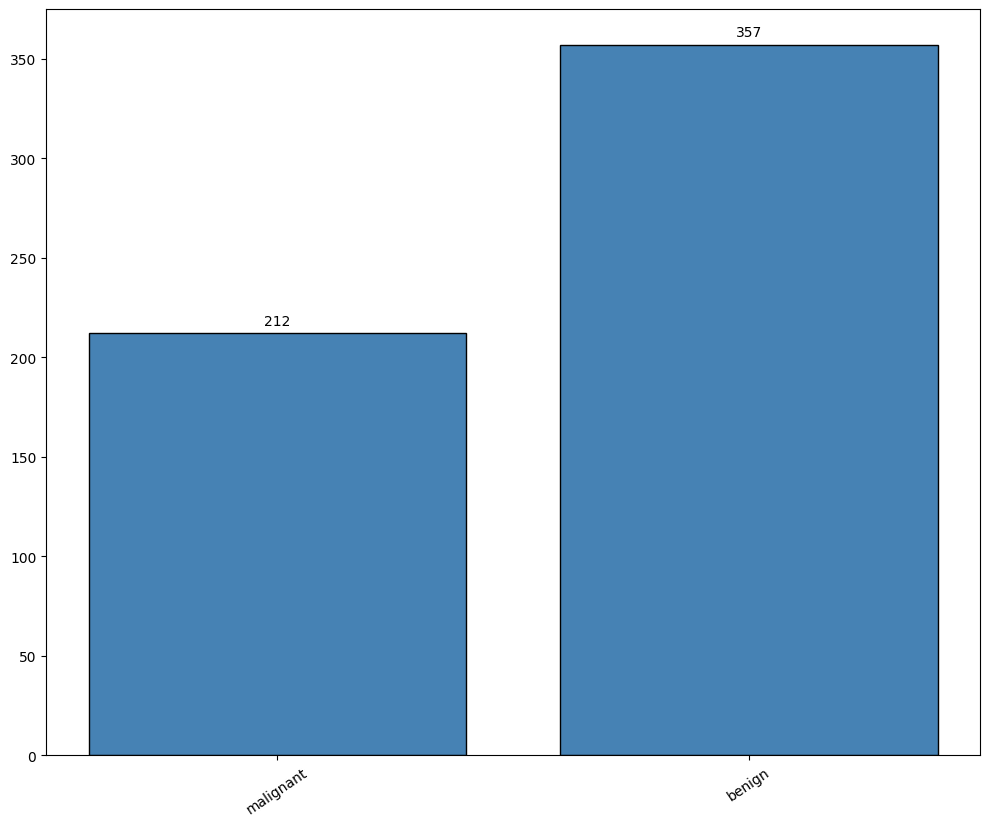

In [33]:
class_counts = np.bincount(data.target)
labels=data.target_names
plt.figure(figsize=(10,8))
bars=plt.bar(
    labels,
    class_counts,
    color="steelblue",
    edgecolor="black"
)
plt.bar_label(bars,padding=4)
plt.tight_layout()
plt.xticks(rotation=34)
plt.show()